<a href="https://colab.research.google.com/github/Madhankumar-17/Day9/blob/main/Accuracy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Logistic Regression for TrafficIQ — Smart Traffic & Congestion Predictor

This section will demonstrate how to build a logistic regression model to classify spam messages using the 'smart_traffic_management_dataset.csv' dataset.

Saving smart_traffic_management_dataset.csv to smart_traffic_management_dataset (1).csv
          timestamp  location_id  traffic_volume  avg_vehicle_speed  \
0  01-01-2024 00:00            4             504          53.124162   
1  01-01-2024 00:01            5             209          44.947850   
2  01-01-2024 00:02            3             572          63.179229   
3  01-01-2024 00:03            5             699          42.269697   
4  01-01-2024 00:04            5             639          72.185791   

   vehicle_count_cars  vehicle_count_trucks  vehicle_count_bikes  \
0                 142                    24                   44   
1                 862                    50                   23   
2                 317                    12                   10   
3                 709                    43                   21   
4                 594                    34                   14   

  weather_condition  temperature   humidity  accident_reported signal_status

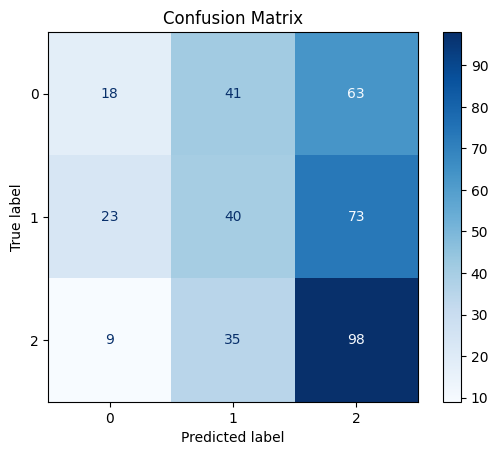


Feature Importance
                Feature  Coefficient  Absolute
4  vehicle_count_trucks     0.055136  0.055136
9     accident_reported     0.051337  0.051337
8              humidity    -0.051330  0.051330
3    vehicle_count_cars    -0.046473  0.046473
1        traffic_volume     0.031317  0.031317
7           temperature    -0.025930  0.025930
0           location_id    -0.024985  0.024985
5   vehicle_count_bikes    -0.024211  0.024211
2     avg_vehicle_speed     0.023234  0.023234
6     weather_condition     0.022861  0.022861


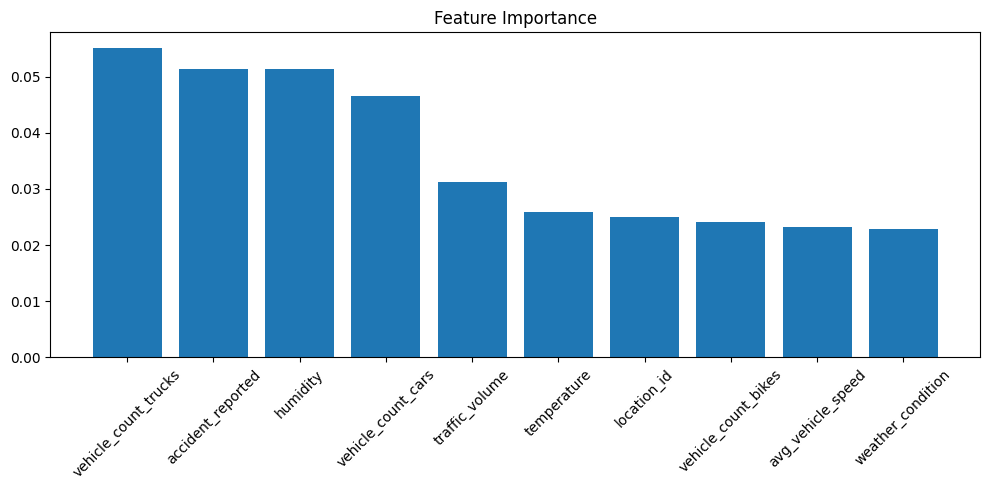


Model Saved Successfully!


In [23]:
# ============================================================
# Smart Traffic Management System
# Logistic Regression + RandomizedSearchCV
# Google Colab
# ============================================================

# Install libraries (if needed)
!pip -q install scikit-learn

import pandas as pd
import matplotlib.pyplot as plt
import joblib

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from scipy.stats import uniform

# ============================================================
# Upload Dataset
# ============================================================

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print(df.head())

# ============================================================
# Drop Timestamp
# ============================================================

df.drop("timestamp", axis=1, inplace=True)

# ============================================================
# Encode Categorical Columns
# ============================================================

encoders = {}

for column in df.columns:
    if df[column].dtype == "object":
        encoder = LabelEncoder()
        df[column] = encoder.fit_transform(df[column])
        encoders[column] = encoder

# ============================================================
# Features and Target
# ============================================================

X = df.drop("signal_status", axis=1)

y = df["signal_status"]

# ============================================================
# Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ============================================================
# Feature Scaling
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================================
# Logistic Regression Model
# ============================================================

model = LogisticRegression(max_iter=1000)

# ============================================================
# Hyperparameter Distribution
# ============================================================

param_dist = {

    "C": uniform(0.01,10),

    "solver":[
        "lbfgs",
        "newton-cg",
        "saga"
    ],

    "penalty":[
        "l2"
    ]
}

# ============================================================
# RandomizedSearchCV
# ============================================================

random_search = RandomizedSearchCV(

    estimator=model,

    param_distributions=param_dist,

    n_iter=20,

    cv=5,

    scoring="accuracy",

    random_state=42,

    n_jobs=-1,

    verbose=2

)

# ============================================================
# Train Model
# ============================================================

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

print("\nBest Parameters")
print(random_search.best_params_)

print("\nBest CV Accuracy")
print(random_search.best_score_)

# ============================================================
# Prediction
# ============================================================

y_pred = best_model.predict(X_test)

# ============================================================
# Accuracy
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("\nTest Accuracy")

print(f"{accuracy*100:.2f}%")

# ============================================================
# Classification Report
# ============================================================

print("\nClassification Report\n")

print(classification_report(y_test, y_pred))

# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

# ============================================================
# Feature Importance
# ============================================================

importance = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": best_model.coef_[0]

})

importance["Absolute"] = importance["Coefficient"].abs()

importance = importance.sort_values(
    by="Absolute",
    ascending=False
)

print("\nFeature Importance")

print(importance)

plt.figure(figsize=(10,5))

plt.bar(
    importance["Feature"],
    importance["Absolute"]
)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.tight_layout()

plt.show()

# ============================================================
# Save Model
# ============================================================

joblib.dump(best_model, "traffic_logistic_randomsearch.pkl")
joblib.dump(scaler, "traffic_scaler.pkl")

print("\nModel Saved Successfully!")

## Decision Tree Classifier + RandomizedSearchCV

In [24]:
from sklearn.tree import DecisionTreeClassifier
from scipy.stats import randint

# ============================================================
# Decision Tree Classifier Model
# ============================================================

dt_model = DecisionTreeClassifier(random_state=42)

# Hyperparameter Distribution
dt_param_dist = {
    "max_depth": randint(1, 20),
    "min_samples_leaf": randint(1, 20),
    "min_samples_split": randint(2, 20),
    "criterion": ["gini", "entropy"]
}

# RandomizedSearchCV
dt_random_search = RandomizedSearchCV(
    estimator=dt_model,
    param_distributions=dt_param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

# Train Model
dt_random_search.fit(X_train, y_train)
best_dt_model = dt_random_search.best_estimator_

print("\nBest Decision Tree Parameters:", dt_random_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Decision Tree Parameters: {'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 11, 'min_samples_split': 9}



Decision Tree Test Accuracy: 31.25%

Classification Report:
               precision    recall  f1-score   support

           0       0.30      0.33      0.31       122
           1       0.28      0.32      0.30       136
           2       0.37      0.30      0.33       142

    accuracy                           0.31       400
   macro avg       0.32      0.31      0.31       400
weighted avg       0.32      0.31      0.31       400



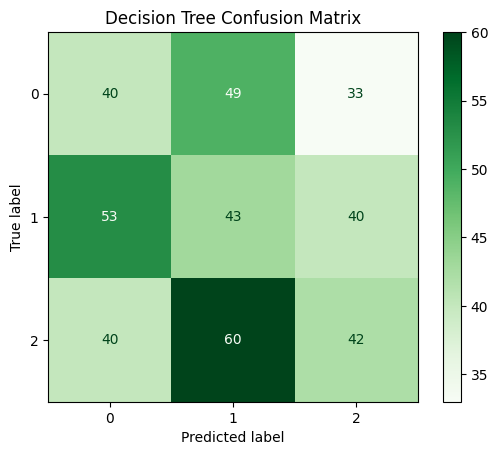

In [25]:
# ============================================================
# Evaluation and Confusion Matrix
# ============================================================

dt_y_pred = best_dt_model.predict(X_test)

print("\nDecision Tree Test Accuracy:", f"{accuracy_score(y_test, dt_y_pred)*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, dt_y_pred))

# Plot Confusion Matrix
dt_cm = confusion_matrix(y_test, dt_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=dt_cm)
disp.plot(cmap="Greens")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [26]:
import joblib
joblib.dump(best_dt_model, "traffic_decision_tree_randomsearch.pkl")
print("Model saved as traffic_decision_tree_randomsearch.pkl")

Model saved as traffic_decision_tree_randomsearch.pkl


### Comparison of Confusion Matrices
This visualization compares the Logistic Regression model (left) with the Decision Tree model (right).

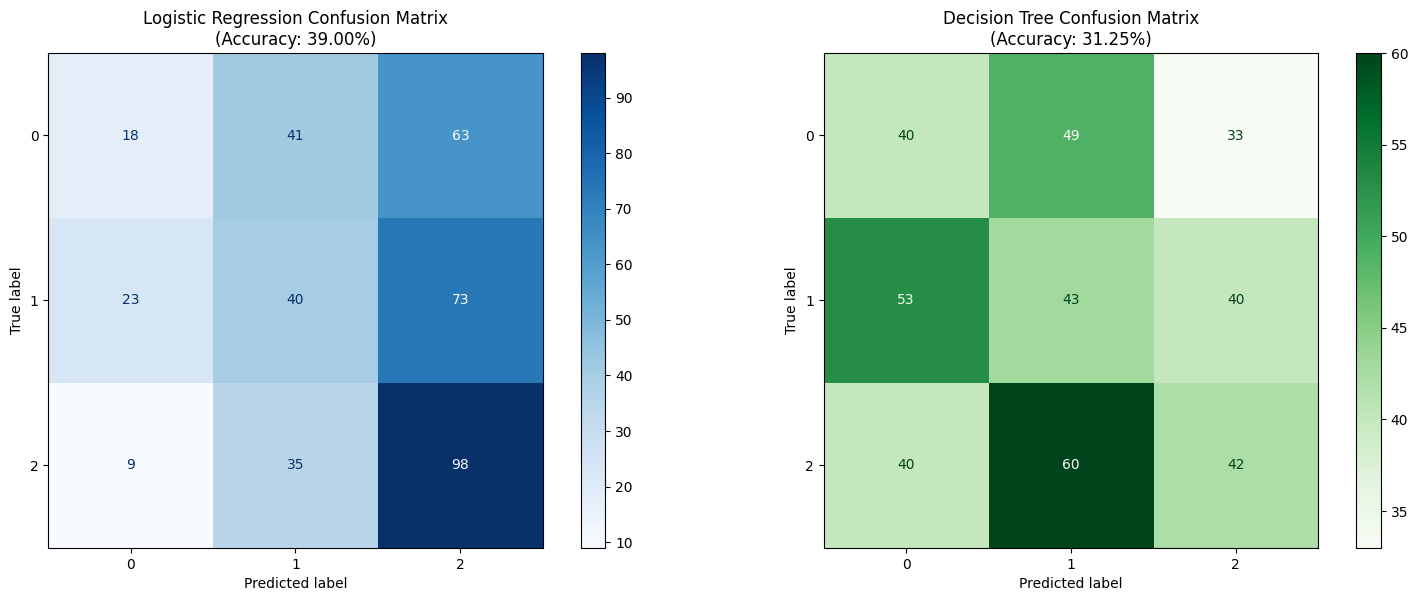

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot Logistic Regression Confusion Matrix
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm)
disp_lr.plot(ax=ax1, cmap='Blues')
ax1.set_title(f'Logistic Regression Confusion Matrix\n(Accuracy: {accuracy*100:.2f}%)')

# Plot Decision Tree Confusion Matrix
disp_dt = ConfusionMatrixDisplay(confusion_matrix=dt_cm)
disp_dt.plot(ax=ax2, cmap='Greens')
ax2.set_title(f'Decision Tree Confusion Matrix\n(Accuracy: {dt_accuracy*100:.2f}%)')

plt.tight_layout()
plt.show()

## Random Forest Classifier + RandomizedSearchCV

In [28]:
from sklearn.ensemble import RandomForestClassifier

# ============================================================
# Random Forest Classifier Model
# ============================================================

rf_model = RandomForestClassifier(random_state=42)

# Hyperparameter Distribution
rf_param_dist = {
    "n_estimators": randint(50, 200),
    "max_depth": randint(1, 20),
    "min_samples_leaf": randint(1, 20),
    "min_samples_split": randint(2, 20),
    "criterion": ["gini", "entropy"]
}

# RandomizedSearchCV
rf_random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_param_dist,
    n_iter=10,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Train Model
rf_random_search.fit(X_train, y_train)
best_rf_model = rf_random_search.best_estimator_

print("\nBest Random Forest Parameters:", rf_random_search.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Random Forest Parameters: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 18, 'min_samples_split': 5, 'n_estimators': 138}



Random Forest Test Accuracy: 32.75%

Classification Report:
               precision    recall  f1-score   support

           0       0.28      0.16      0.20       122
           1       0.33      0.32      0.33       136
           2       0.34      0.48      0.40       142

    accuracy                           0.33       400
   macro avg       0.32      0.32      0.31       400
weighted avg       0.32      0.33      0.31       400



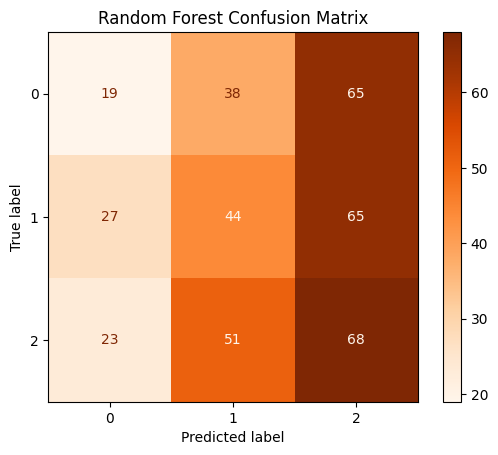

In [29]:
# ============================================================
# Evaluation and Confusion Matrix
# ============================================================

rf_y_pred = best_rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_y_pred)

print(f"\nRandom Forest Test Accuracy: {rf_accuracy*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, rf_y_pred))

# Plot Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm)
disp.plot(cmap="Oranges")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [30]:
joblib.dump(best_rf_model, "traffic_rf_randomsearch.pkl")
print("Model saved as traffic_rf_randomsearch.pkl")

Model saved as traffic_rf_randomsearch.pkl


### Comparison of Logistic Regression vs. Random Forest
This visualization allows us to compare the classification performance of the Logistic Regression model (Accuracy: 39.00%) and the Random Forest model (Accuracy: 32.75%).

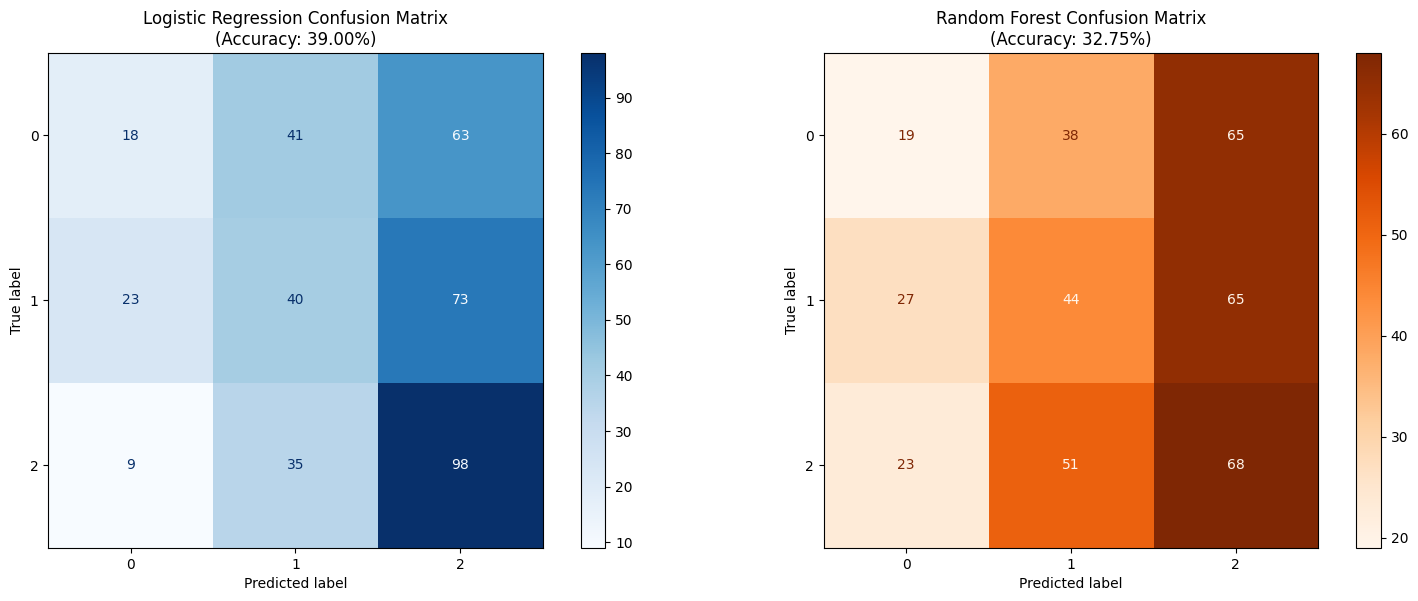

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot Logistic Regression Confusion Matrix
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm)
disp_lr.plot(ax=ax1, cmap='Blues')
ax1.set_title(f'Logistic Regression Confusion Matrix\n(Accuracy: {accuracy*100:.2f}%)')

# Plot Random Forest Confusion Matrix
disp_rf = ConfusionMatrixDisplay(confusion_matrix=rf_cm)
disp_rf.plot(ax=ax2, cmap='Oranges')
ax2.set_title(f'Random Forest Confusion Matrix\n(Accuracy: {rf_accuracy*100:.2f}%)')

plt.tight_layout()
plt.show()

### Final Comparison: All Models
This final visualization compares the classification performance of all three implemented models: Logistic Regression, Decision Tree, and Random Forest.

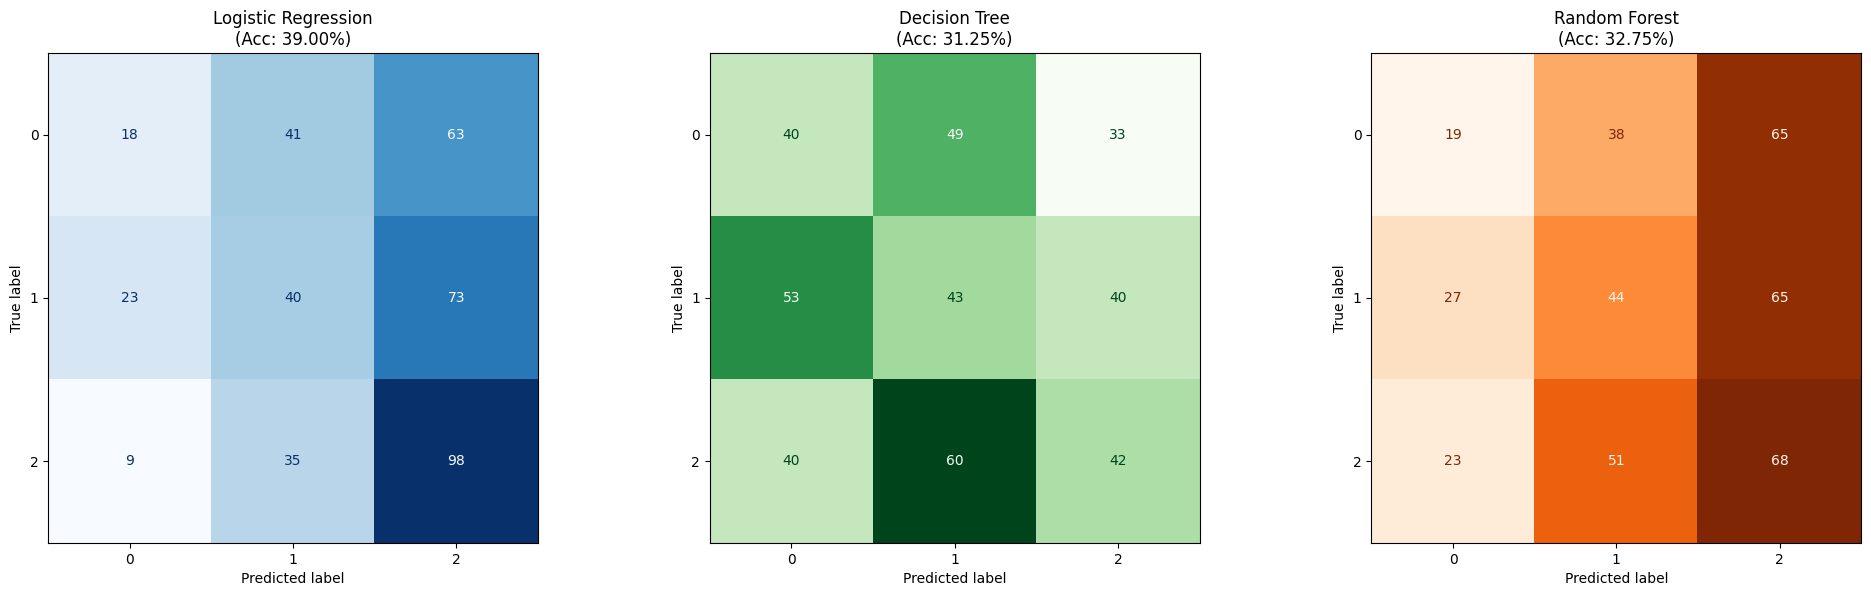

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create a figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# Plot Logistic Regression Confusion Matrix
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm)
disp_lr.plot(ax=ax1, cmap='Blues', colorbar=False)
ax1.set_title(f'Logistic Regression\n(Acc: {accuracy*100:.2f}%)')

# Plot Decision Tree Confusion Matrix
disp_dt = ConfusionMatrixDisplay(confusion_matrix=dt_cm)
disp_dt.plot(ax=ax2, cmap='Greens', colorbar=False)
ax2.set_title(f'Decision Tree\n(Acc: {dt_accuracy*100:.2f}%)')

# Plot Random Forest Confusion Matrix
disp_rf = ConfusionMatrixDisplay(confusion_matrix=rf_cm)
disp_rf.plot(ax=ax3, cmap='Oranges', colorbar=False)
ax3.set_title(f'Random Forest\n(Acc: {rf_accuracy*100:.2f}%)')

plt.tight_layout()
plt.show()